# Discharge timeseries
***

***Author:** Chus Casado Rodríguez*<br>
***Date:** 30-04-2025*<br>

**Introduction**<br>
This notebook analyses the daily time series of river discharge to the oceans, and it produces time series of annual and monthly anomalies.

**Output**<br>
* *discharge_annual_anomaly_by_ocean.csv*: yearly time series of discharge anomaly (km3/year) from 1979 to 2024 compared with the period 1991-2020, disaggregated by ocean.
* *discharge_montly_anomaly_by_ocean.nc*: monthly time series of discharge anomaly (km3/year) from 1979 to 2024 compared with the monthly averages in the period 1991-2020, disaggregated by ocean.
* *discharge_seasonality_by_ocean.nc*:  monthly climatology of dicharge (mean and standard deviation) for the period 1991-2020, and the monthly values in 2024, disaggregated by ocean.

In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import numpy as np
import pandas as pd
import geopandas as gpd
# from shapely.geometry import Point
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from scipy.stats import linregress

## Configuration

In [2]:
VAR = 'discharge'

# inputs
PATH_IN = Path('../data/GloFAS') / VAR
POINTS_FILE = PATH_IN / 'outlets_5000km2_ocean.shp'
TS_FILE = PATH_IN / f'{VAR}_outlets.nc'

# outputs
PATH_OUT = Path('Z:/nahaUsers/casadje/GloFASv5/stations/Arctic')
PATH_PLOT = PATH_OUT / 'plots'
PATH_PLOT.mkdir(parents=True, exist_ok=True)

# climatology
START = datetime(1980, 1, 1)
END = datetime(2022, 12, 31)

map_variables = {
    'runoff': 'rowe',
    'discharge': 'dis24'
}

var_shortname = map_variables[VAR]

In [3]:
points = {
    177: 'Ob',
    76: 'Yenisei',
    56: 'Lena',
    110: 'Kolyma',
    230: 'Yukon',
    128: 'Mackenzie'
}

## Data

### River outlets

In [4]:
# load modified river outlets
outlets = gpd.read_file(POINTS_FILE).set_index('ID', drop=True)

### Discharge time series

In [5]:
# load extracted discharge time series at the outlets
dis = xr.open_dataset(TS_FILE)[var_shortname]

# rename or drop variables
dis = dis.drop_vars('surface', errors='ignore')
dis = dis.rename({'valid_time': 'time'})

# convert time convention to beginning-of-timestep
dis['time'] = dis['time'] - pd.Timedelta(days=1)
dis = dis.sel(time=slice(datetime(1980, 1, 1), datetime(2025, 1, 1)))

# select points
dis = dis.sel(ID=list(points)).to_pandas()

In [6]:
# export time series
for ID, river in points.items():
    dis[ID].to_csv(PATH_OUT / f'{river}.csv', header=None)

In [11]:
# annual average
dis = dis.loc[START:END]
dis_y = dis.groupby(dis.index.year).mean()

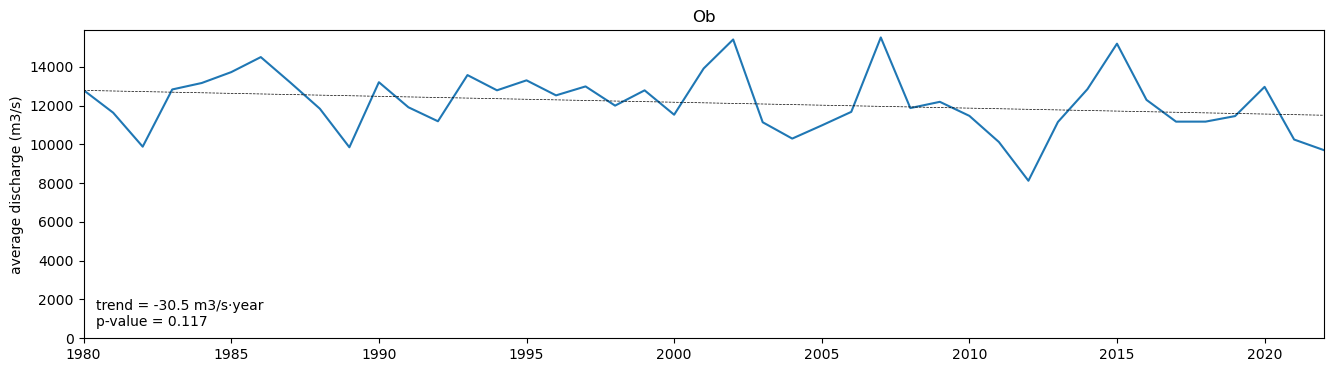

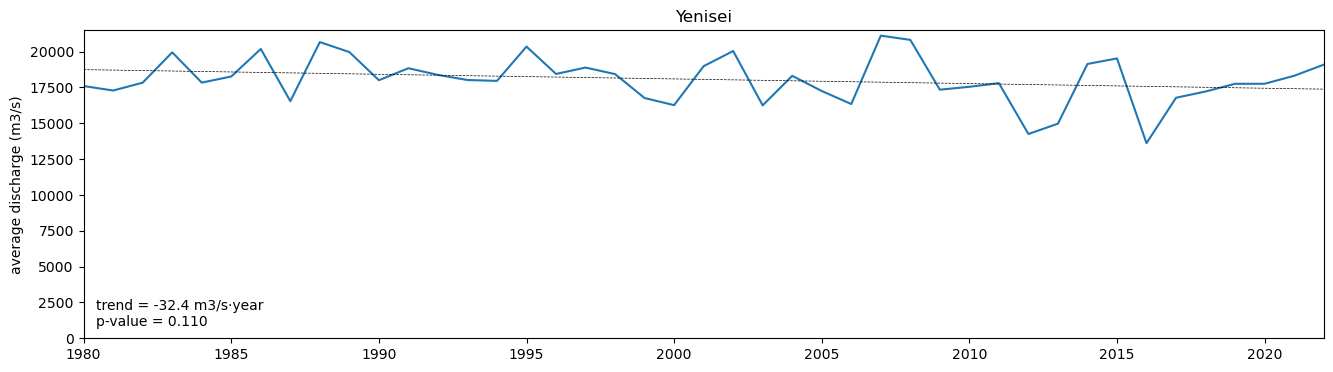

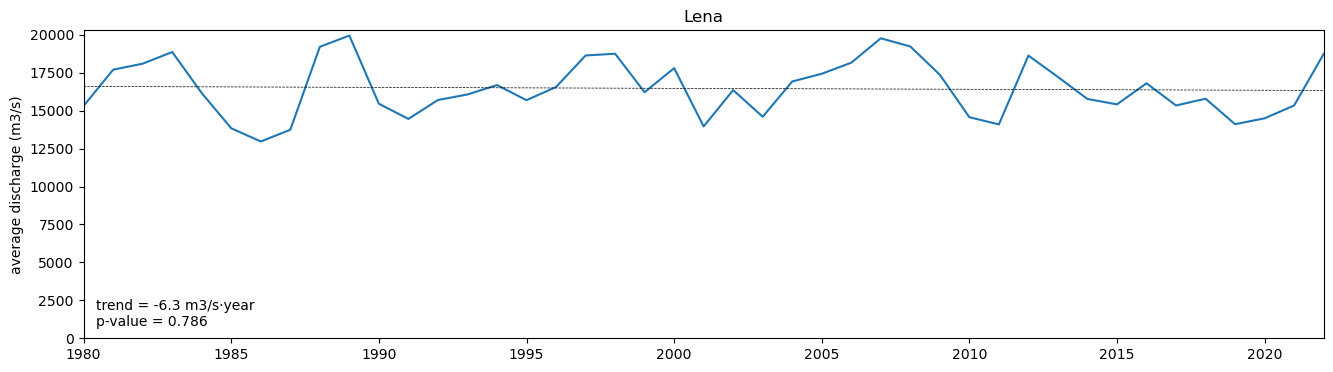

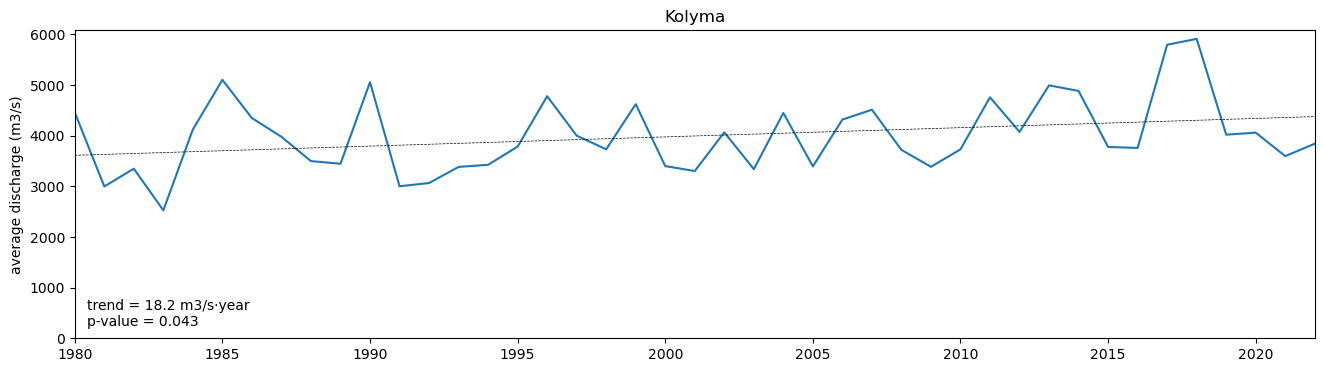

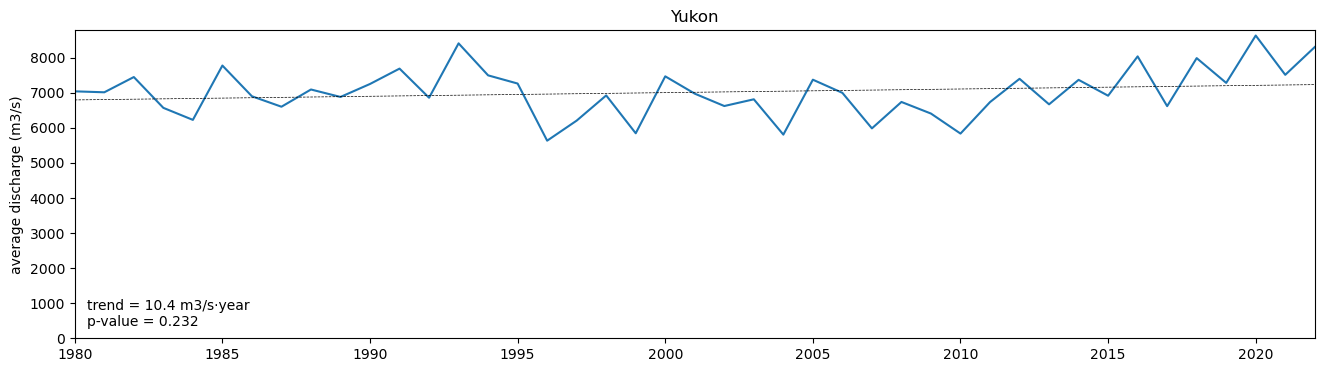

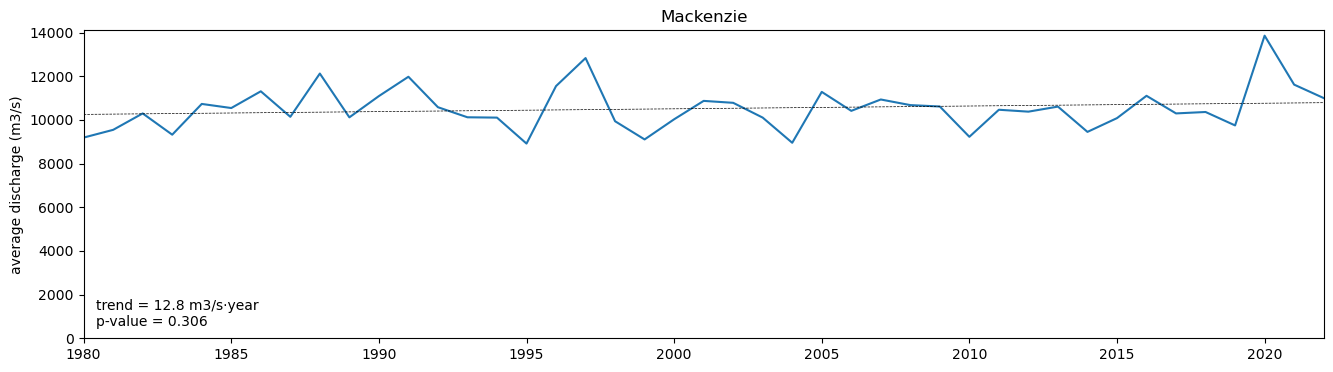

In [15]:
alpha = .05

for ID, river in points.items():
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(dis_y[ID])
    # linear regression
    slope, intercept, r_value, p_value, std_error = linregress(dis_y.index, dis_y[ID])
    # if p_value <= alpha:
    ax.plot(dis_y.index, intercept + dis_y.index * slope, c='k', ls='--', lw=.5)
    ax.text(0.01, 0.04, f'trend = {slope:.1f} m3/s·year\np-value = {p_value:.3f}', transform=ax.transAxes)
    ax.set(
        xlim=(dis_y.index.min(), dis_y.index.max()),
        ylim=(0, None),
        ylabel='average discharge (m3/s)',
        title=river
    )
    plt.savefig(PATH_PLOT / f'average_annual_discharge_{river}.jpg', dpi=300, bbox_inches='tight')